## Reglas de asociación - Canastas

Se preparan y analizan las transacciones de `data/final/` dada la columna `canasta`

### Imports

In [1]:
import os, socket
from pathlib import Path

import matplotlib.pyplot as plt
from pyspark.sql import SparkSession, functions as F

%matplotlib inline
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": .3})

### Utilidades

- Constantes

In [2]:
proyecto = Path.cwd()
while not (proyecto / "docker-compose.yml").exists() and proyecto != proyecto.parent:
    proyecto = proyecto.parent 
final_dir = proyecto / "data" / "final"
out_dir = proyecto / "05_Asociacion" / "temp" / "a_canastas"
out_dir.mkdir(parents=True, exist_ok=True)

- Spark

In [3]:
spark_master = os.environ.get("spark_master", "local[*]")

builder = (SparkSession.builder
           .appName("asociacion-canastas")
           .master(spark_master)
           .config("spark.driver.memory",   os.environ.get("SPARK_DRIVER_MEMORY", "2g"))
           .config("spark.executor.memory", os.environ.get("SPARK_EXECUTOR_MEMORY", "2g"))
           .config("spark.sql.shuffle.partitions", "24")
           .config("spark.ui.showConsoleProgress", "false")
           .config("spark.sql.session.timeZone", "America/Lima"))

if spark_master.startswith("spark://"):
    builder = (builder.config("spark.driver.host", socket.gethostname())
                      .config("spark.driver.bindAddress", "0.0.0.0"))

spark = builder.getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

### Verificación del cluster

In [4]:
sc = spark.sparkContext
estado = sc._jsc.sc().getExecutorMemoryStatus()

print(f"Master        : {sc.master}")
print(f"Executors     : {estado.size() - 1}")
print(f"Cores totales : {sc.defaultParallelism}")
print(f"Memoria driver: {sc._jvm.java.lang.Runtime.getRuntime().maxMemory() / 1024**3:.1f} GB")
print("UI del job    : http://localhost:4040")

Master        : spark://spark-master:7077
Executors     : 0
Cores totales : 2
Memoria driver: 2.0 GB
UI del job    : http://localhost:4040


---
### 1. Carga de data

In [5]:
assert final_dir.exists(), f"No se encuentra {final_dir}; corre 01_EDA_KDD/KDD/a_transformaciones.ipynb"

procesos = spark.read.parquet(str(final_dir)).select(
    "ocid", "anio", "mes", "entidad", "region", "metodo_detalle",
    "categoria", "tramo_monto", "rubro", "canasta", "postor_unico").cache()

N = procesos.count()
print(f"Dataset cargado: {N:,} filas")

Dataset cargado: 235,954 filas


### 2. Estructura de transacción

- Cada proceso (`ocid`) = una transacción

- Ítems: `cat=`, `met=`, `reg=`, `monto=`, `rubro=` (multivalor), `comp=postor_unico` `comp=varios_postores`.

### 3. Estadísticas

#### a. Distribución

In [6]:
tam = procesos.select(F.size("canasta").alias("tam"))
tam.selectExpr("min(tam) as minimo", "percentile_approx(tam, 0.5) as mediana", "max(tam) as maximo").show()

+------+-------+------+
|minimo|mediana|maximo|
+------+-------+------+
|     4|      6|    20|
+------+-------+------+



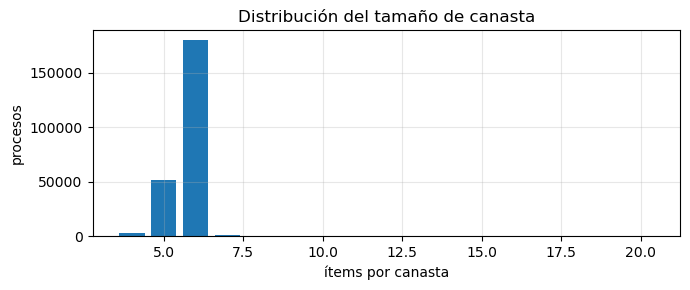

In [7]:
tam_pd = tam.groupBy("tam").count().orderBy("tam").toPandas()
plt.figure(figsize=(7, 3))
plt.bar(tam_pd["tam"], tam_pd["count"])
plt.xlabel("ítems por canasta"); plt.ylabel("procesos"); plt.title("Distribución del tamaño de canasta")
plt.tight_layout(); plt.show()

#### b. Items distintos

In [8]:
items = (procesos.select(F.explode("canasta").alias("item"))
         .groupBy("item")
         .count()
         .withColumnRenamed("count", "soporte_abs")
         .withColumn("soporte_pct", F.round(100 * F.col("soporte_abs") / N, 1))
         .orderBy(F.desc("soporte_abs")))

n_items_distintos = items.count()
print(f"Ítems distintos: {n_items_distintos}")
items.show(15, truncate=False)

Ítems distintos: 304


+--------------------------------+-----------+-----------+
|item                            |soporte_abs|soporte_pct|
+--------------------------------+-----------+-----------+
|comp=varios_postores            |188411     |79.9       |
|cat=GOODS                       |105193     |44.6       |
|monto=2_50k-200k                |104222     |44.2       |
|cat=SERVICES                    |103642     |43.9       |
|met=ADJUDICACIÓN SIMPLIFICADA   |103367     |43.8       |
|monto=3_200k-1M                 |70887      |30.0       |
|reg=LIMA                        |68464      |29.0       |
|rubro=72                        |54647      |23.2       |
|rubro=81                        |27667      |11.7       |
|cat=WORKS                       |27119      |11.5       |
|met=SUBASTA INVERSA ELECTRÓNICA |27042      |11.5       |
|comp=postor_unico               |26380      |11.2       |
|monto=4_1M-5M                   |24361      |10.3       |
|met=LICITACIÓN PÚBLICA ABREVIADA|15719      |6.7       

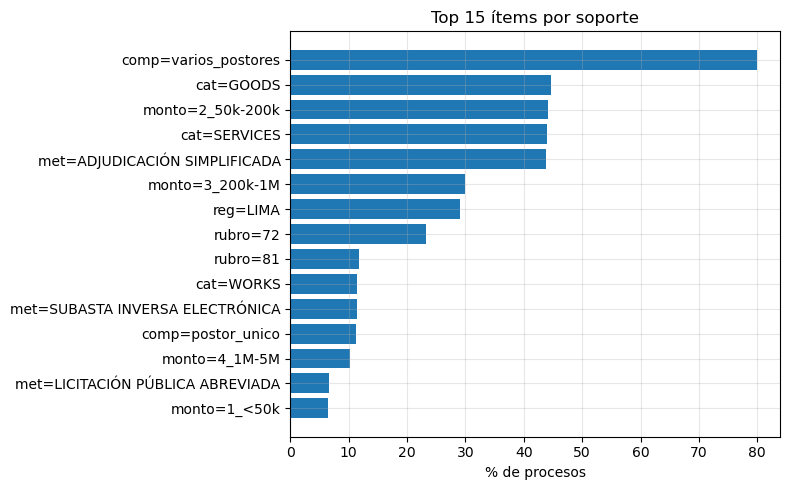

In [9]:
top_items = items.limit(15).toPandas().iloc[::-1]
plt.figure(figsize=(8, 5))
plt.barh(top_items["item"], top_items["soporte_pct"])
plt.xlabel("% de procesos"); plt.title("Top 15 ítems por soporte")
plt.tight_layout(); plt.show()

- 304 ítems distintos, canasta de 4-20 ítems (mediana 6)

- Soporte varía mucho: `comp=varios_postores` domina (79.9%), `cat=GOODS`/`met=ADJUDICACIÓN SIMPLIFICADA` `monto=2_50k-200k` rondan 44%, y `comp=postor_unico` tiene 11.2% de soporte 

- Con 79.9% vs 11.2%, `comp=` sí varía y las reglas hacia `postor_unico` seran reales

### 4. Subconjunto - Apriori Q4 2025

Apriori no escala muy bien, entonces se usa un subconjunto real y justificable (el trimestre más reciente)

In [10]:
q4_2025 = procesos.where("anio = 2025 AND mes >= 10")
n_q4 = q4_2025.count()
print(f"Q4 2025 (meses 10-12): {n_q4:,} filas de {N:,} totales ({100*n_q4/N:.1f}%)")

Q4 2025 (meses 10-12): 23,862 filas de 235,954 totales (10.1%)


### 5. Escritura de canastas

Se escriben las canastas a `temp/a_canastas`

In [11]:
procesos.select("ocid", "canasta").write.mode("overwrite").parquet(str(out_dir / "full"))
q4_2025.select("ocid", "canasta").write.mode("overwrite").parquet(str(out_dir / "q4_2025"))
items.write.mode("overwrite").parquet(str(out_dir / "support_full"))

print("Escrito en temp/a_canastas/: full, q4_2025, support_full")

Escrito en temp/a_canastas/: full, q4_2025, support_full


#### a. Verificación

In [12]:
chk_full = spark.read.parquet(str(out_dir / "full")).count()
chk_q4 = spark.read.parquet(str(out_dir / "q4_2025")).count()
chk_items = spark.read.parquet(str(out_dir / "support_full")).count()

assert chk_full == N, f"full: esperaba {N}, leí {chk_full}"
assert chk_q4 == n_q4, f"q4_2025: esperaba {n_q4}, leí {chk_q4}"
assert chk_items == n_items_distintos, f"support_full: esperaba {n_items_distintos}, leí {chk_items}"
print(f"OK: full={chk_full:,} | q4_2025={chk_q4:,} | support_full={chk_items}")

OK: full=235,954 | q4_2025=23,862 | support_full=304


---
### 6. Cerrar sesión

In [13]:
spark.stop()